<a href="https://colab.research.google.com/github/dystaSatria/Deep-Learning/blob/main/Internship%20Projects/precision/precision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== DENSENET PRECISION ANALIZI ===

Örnek Veri:
Gerçek etiketler:    [0 1 2 0 1 2 0 1 2 0 1 2]
Tahmin edilen:       [0 1 1 0 0 2 0 1 2 1 1 2]
Sınıf isimleri:      ['Kedi', 'Köpek', 'Kuş']

=== GENEL PRECISION SONUÇLARI ===
Macro Precision:     0.7833
Micro Precision:     0.7500
Weighted Precision:  0.7833

=== SINIF BAZINDA PRECISION ===
Kedi: 0.7500
Köpek: 0.6000
Kuş: 1.0000

=== MANUEL PRECISION HESAPLAMA ===

0 sınıfı için:
True Positive (TP): 3
False Positive (FP): 1
Precision: 3/4 = 0.7500

1 sınıfı için:
True Positive (TP): 3
False Positive (FP): 2
Precision: 3/5 = 0.6000

2 sınıfı için:
True Positive (TP): 3
False Positive (FP): 0
Precision: 3/3 = 1.0000

=== DETAYLI CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        Kedi       0.75      0.75      0.75         4
       Köpek       0.60      0.75      0.67         4
         Kuş       1.00      0.75      0.86         4

    accuracy                           0.75        12
   macro avg       

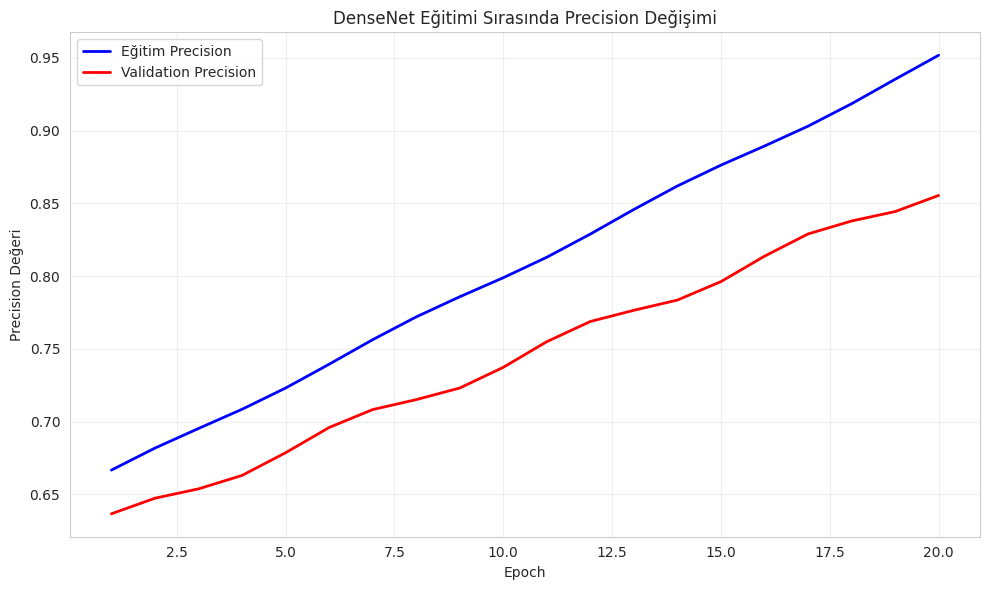

In [6]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import precision_score, classification_report
import numpy as np

class SimpleDenseNetPrecision:
    def __init__(self, num_classes=3):
        """
        Basit DenseNet precision hesaplama örneği
        """
        self.model = models.densenet121(pretrained=True)
        # Son katmanı özelleştir
        self.model.classifier = nn.Linear(self.model.classifier.in_features, num_classes)
        self.model.eval()  # Değerlendirme modu

    def precision_hesapla(self, gercek_etiketler, tahmin_edilen):
        """
        Farklı yöntemlerle precision hesapla

        Args:
            gercek_etiketler: Gerçek sınıf etiketleri
            tahmin_edilen: Model tarafından tahmin edilen etiketler
        """

        # 1. Macro Precision (her sınıfın precision'ının ortalaması)
        macro_precision = precision_score(gercek_etiketler, tahmin_edilen, average='macro')

        # 2. Micro Precision (genel doğruluk)
        micro_precision = precision_score(gercek_etiketler, tahmin_edilen, average='micro')

        # 3. Weighted Precision (sınıf dağılımına göre ağırlıklı)
        weighted_precision = precision_score(gercek_etiketler, tahmin_edilen, average='weighted')

        # 4. Sınıf bazında precision
        per_class_precision = precision_score(gercek_etiketler, tahmin_edilen, average=None)

        return {
            'macro': macro_precision,
            'micro': micro_precision,
            'weighted': weighted_precision,
            'per_class': per_class_precision
        }

    def manuel_precision_hesapla(self, gercek_etiketler, tahmin_edilen, sinif_adi):
        """
        Belirli bir sınıf için manuel precision hesaplama

        Precision = TP / (TP + FP)
        TP: True Positive - Doğru pozitif tahminler
        FP: False Positive - Yanlış pozitif tahminler
        """

        # True Positive: Bu sınıfı doğru tahmin ettiklerimiz
        tp = sum((g == sinif_adi) and (t == sinif_adi)
                for g, t in zip(gercek_etiketler, tahmin_edilen))

        # False Positive: Bu sınıfı yanlış tahmin ettiklerimiz
        fp = sum((g != sinif_adi) and (t == sinif_adi)
                for g, t in zip(gercek_etiketler, tahmin_edilen))

        # Precision hesaplama
        if tp + fp == 0:
            return 0.0

        precision = tp / (tp + fp)

        print(f"\n{sinif_adi} sınıfı için:")
        print(f"True Positive (TP): {tp}")
        print(f"False Positive (FP): {fp}")
        print(f"Precision: {tp}/{tp + fp} = {precision:.4f}")

        return precision

# Örnek kullanım
def precision_ornegi():
    """
    DenseNet precision hesaplama örneği
    """

    # Örnek veri (3 sınıf: 0=Kedi, 1=Köpek, 2=Kuş)
    gercek_etiketler = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2])
    tahmin_edilen = np.array([0, 1, 1, 0, 0, 2, 0, 1, 2, 1, 1, 2])

    sinif_isimleri = ['Kedi', 'Köpek', 'Kuş']

    # DenseNet precision hesaplayıcı
    precision_calc = SimpleDenseNetPrecision(num_classes=3)

    print("=== DENSENET PRECISION ANALIZI ===\n")

    print("Örnek Veri:")
    print(f"Gerçek etiketler:    {gercek_etiketler}")
    print(f"Tahmin edilen:       {tahmin_edilen}")
    print(f"Sınıf isimleri:      {sinif_isimleri}")

    # Genel precision hesaplama
    precision_sonuclari = precision_calc.precision_hesapla(gercek_etiketler, tahmin_edilen)

    print(f"\n=== GENEL PRECISION SONUÇLARI ===")
    print(f"Macro Precision:     {precision_sonuclari['macro']:.4f}")
    print(f"Micro Precision:     {precision_sonuclari['micro']:.4f}")
    print(f"Weighted Precision:  {precision_sonuclari['weighted']:.4f}")

    print(f"\n=== SINIF BAZINDA PRECISION ===")
    for i, (sinif_adi, precision_deger) in enumerate(zip(sinif_isimleri, precision_sonuclari['per_class'])):
        print(f"{sinif_adi}: {precision_deger:.4f}")

    # Manuel hesaplama örneği
    print(f"\n=== MANUEL PRECISION HESAPLAMA ===")
    for i, sinif_adi in enumerate(sinif_isimleri):
        precision_calc.manuel_precision_hesapla(gercek_etiketler, tahmin_edilen, i)

    # Detaylı classification report
    print(f"\n=== DETAYLI CLASSIFICATION REPORT ===")
    report = classification_report(gercek_etiketler, tahmin_edilen,
                                 target_names=sinif_isimleri)
    print(report)

# DenseNet için precision iyileştirme stratejileri
def precision_iyilestirme_stratejileri():
    """
    DenseNet'te precision'ı iyileştirmek için stratejiler
    """

    stratejiler = {
        "Veri Ön İşleme": [
            "Veri augmentation (döndürme, ölçekleme, renk değişimi)",
            "Veri normalizasyonu ve standardizasyonu",
            "Dengesiz veri setleri için class balancing",
            "Outlier tespiti ve temizleme"
        ],

        "Model Mimarisi": [
            "Uygun dense block sayısı seçimi",
            "Growth rate parametresinin optimizasyonu",
            "Dropout oranının fine-tuning",
            "Transition layer'ların optimize edilmesi"
        ],

        "Eğitim Stratejileri": [
            "Learning rate scheduling",
            "Uygun loss function seçimi (CrossEntropy, Focal Loss)",
            "Weight decay ve L2 regularization",
            "Batch normalization kullanımı"
        ],

        "Değerlendirme": [
            "Cross-validation kullanımı",
            "Confusion matrix analizi",
            "ROC-AUC curve incelemesi",
            "Precision-Recall curve analizi"
        ]
    }

    print("=== DENSENET PRECISION İYİLEŞTİRME STRATEJİLERİ ===\n")

    for kategori, onneriler in stratejiler.items():
        print(f"📊 {kategori}:")
        for onneri in onneriler:
            print(f"   • {onneri}")
        print()

# DenseNet'te Precision Optimizasyonu için İleri Düzey Teknikler
def ileri_duzey_precision_teknikleri():
    """
    DenseNet'te precision'ı maksimize etmek için ileri düzey teknikler
    """

    print("=== İLERİ DÜZEY PRECISION OPTİMİZASYON TEKNİKLERİ ===\n")

    print("🔬 1. Ensemble Yöntemleri:")
    print("   • Birden fazla DenseNet modelini birleştirerek prediction uncertainty azaltma")
    print("   • Voting mechanisms ve weighted averaging ile robust tahminler")
    print("   • Bagging ve boosting teknikleri ile precision stabilizasyonu")
    print()

    print("🎯 2. Threshold Optimization:")
    print("   • ROC curve analizi ile optimal decision threshold belirleme")
    print("   • Precision-Recall curve'dan hareketle class-specific threshold ayarlama")
    print("   • Cost-sensitive learning ile false positive maliyetini minimize etme")
    print()

    print("⚡ 3. Transfer Learning Stratejileri:")
    print("   • ImageNet pre-trained weights'ten domain-specific fine-tuning")
    print("   • Layer-wise learning rate adjustment ile precision maximization")
    print("   • Feature extraction vs fine-tuning trade-off analizi")

def precision_monitoring_sistemi():
    """
    Eğitim sırasında precision takip sistemi
    """
    import matplotlib.pyplot as plt

    # Örnek precision değişim grafiği
    epochs = list(range(1, 21))
    train_precision = [0.65 + 0.015*i + 0.002*np.sin(i) for i in epochs]
    val_precision = [0.62 + 0.012*i + 0.005*np.sin(i*1.2) for i in epochs]

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_precision, 'b-', label='Eğitim Precision', linewidth=2)
    plt.plot(epochs, val_precision, 'r-', label='Validation Precision', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Precision Değeri')
    plt.title('DenseNet Eğitimi Sırasında Precision Değişimi')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    print("📈 Precision Monitoring Sistemi Özellikleri:")
    print("   • Real-time precision tracking")
    print("   • Early stopping mechanisms")
    print("   • Validation precision platolarını tespit etme")
    print("   • Learning rate scheduling için precision-based triggers")

if __name__ == "__main__":
    # Precision hesaplama örneğini çalıştır
    precision_ornegi()

    print("\n" + "="*60 + "\n")

    # İyileştirme stratejilerini göster
    precision_iyilestirme_stratejileri()

    print("\n" + "="*60 + "\n")

    # İleri düzey teknikleri göster
    ileri_duzey_precision_teknikleri()

    print("\n" + "="*60 + "\n")

    # Precision monitoring sistemi
    precision_monitoring_sistemi()